In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
df = pd.read_csv("insurance.csv")

In [ ]:
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [ ]:
# EDA

df.shape

(1338, 7)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [ ]:
df.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


In [ ]:
df.isnull().sum()

,0
age,0
sex,0
bmi,0
children,0
smoker,0
region,0
charges,0


In [ ]:
numeric_cols = ["age", "bmi", "children", "charges"]

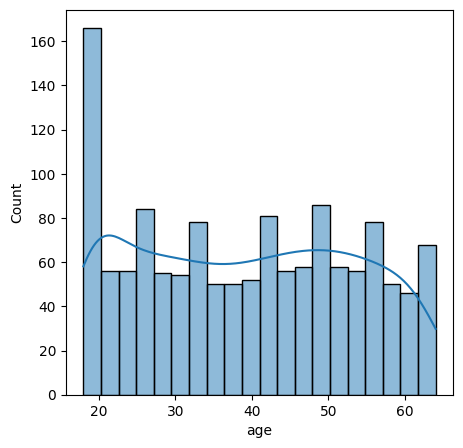

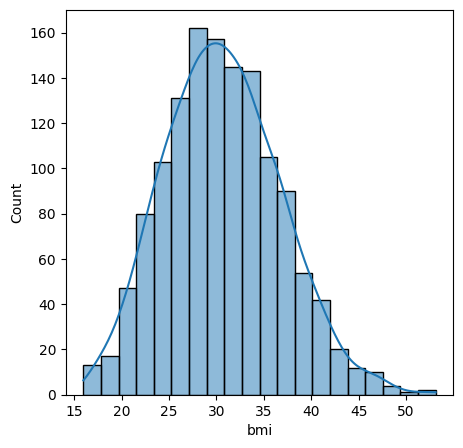

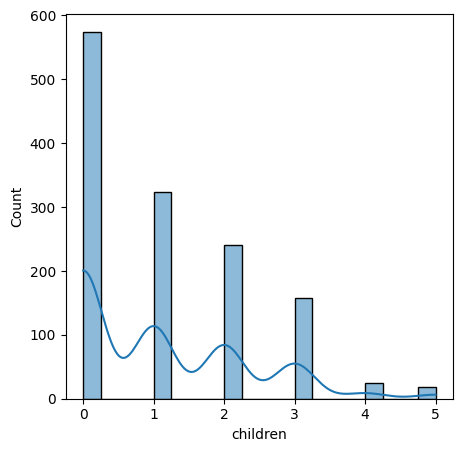

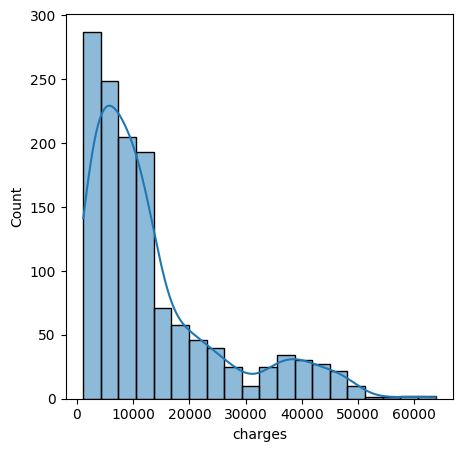

In [ ]:
for col in numeric_cols:
    plt.figure(figsize=(5, 5))
    sns.histplot(df[col], kde = True, bins = 20)

<Axes: xlabel='children', ylabel='count'>

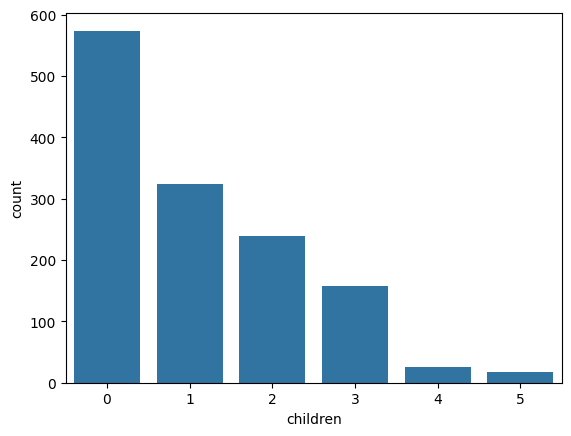

In [ ]:
sns.countplot(x = df["children"])

<Axes: xlabel='sex', ylabel='count'>

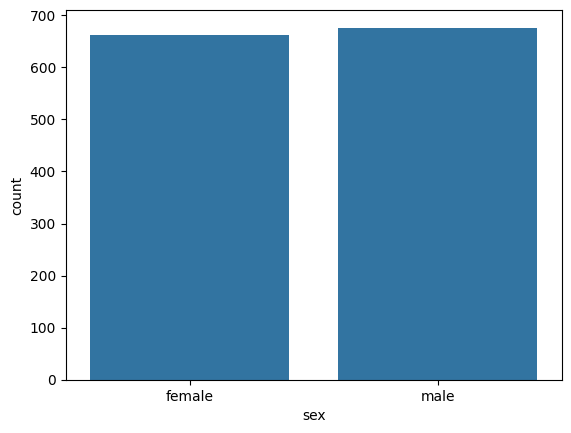

In [ ]:
sns.countplot(x = df["sex"])

<Axes: xlabel='smoker', ylabel='count'>

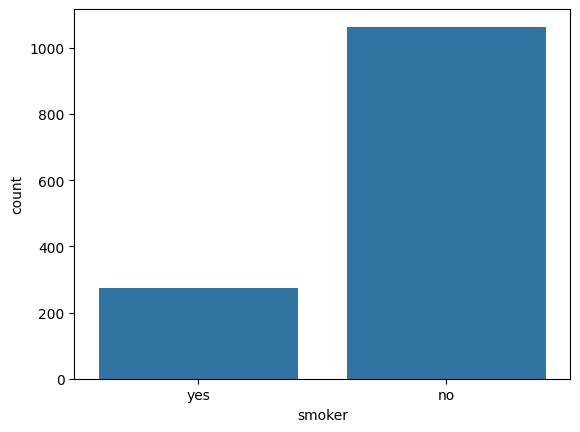

In [ ]:
sns.countplot(x = df["smoker"])

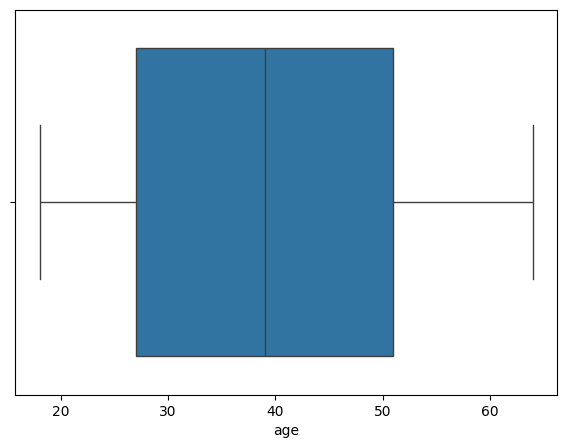

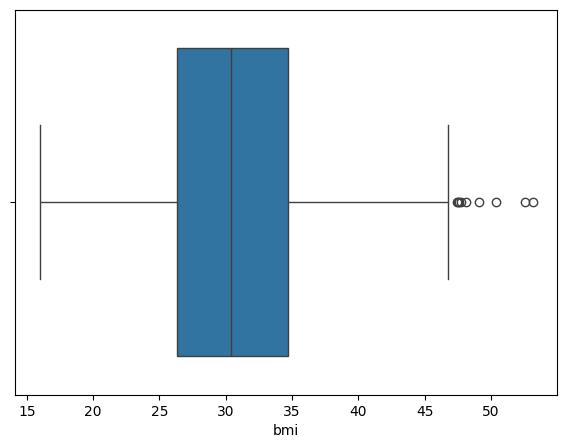

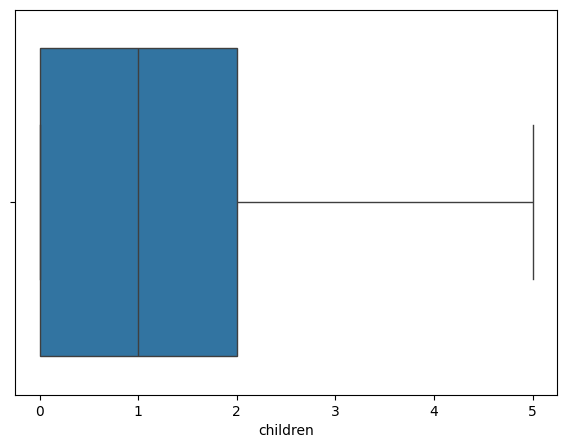

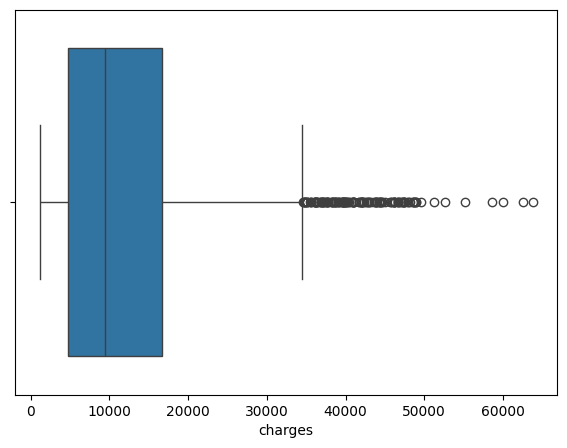

In [ ]:
for col in numeric_cols:
    plt.figure(figsize=(7, 5))
    sns.boxplot(x = df[col])

<Axes: >

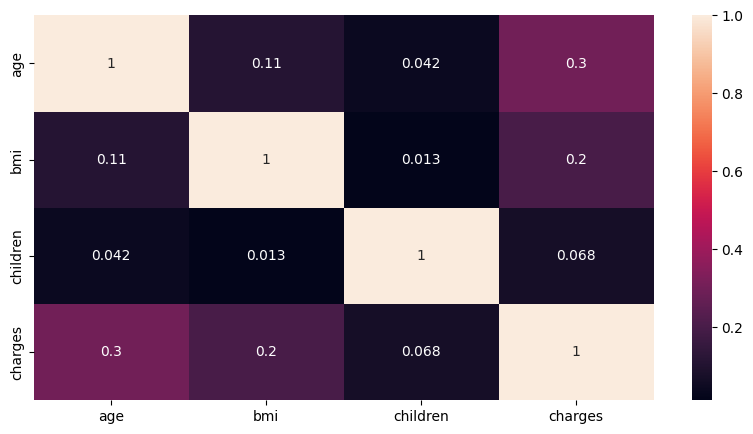

In [ ]:
plt.figure(figsize=(10, 5))
sns.heatmap(df.corr(numeric_only = True), annot = True)

In [ ]:
# Data Cleaning and Preprocessing

df_cleaned = df.copy()

In [ ]:
df_cleaned.drop_duplicates(inplace = True)

In [ ]:
df.shape

(1338, 7)

In [ ]:
df_cleaned.dtypes

,0
age,int64
sex,object
bmi,float64
children,int64
smoker,object
region,object
charges,float64


In [ ]:
df_cleaned["sex"].value_counts()

,count
sex,
male,675
female,662


In [ ]:
df_cleaned["sex"] = df_cleaned["sex"].map({"male": 0, "female": 1})

In [ ]:
df_cleaned["smoker"].value_counts()

,count
smoker,
no,1063
yes,274


In [ ]:
df_cleaned["smoker"] = df_cleaned["smoker"].map({"no": 0, "yes": 1})

In [ ]:
df_cleaned["region"].value_counts()

,count
region,
southeast,364
southwest,325
northwest,324
northeast,324


In [ ]:
df_cleaned = pd.get_dummies(df_cleaned, columns = ["region"])

In [ ]:
df_cleaned.head()

,age,sex,bmi,children,smoker,charges,region_northeast,region_northwest,region_southeast,region_southwest
0,19,1,27.900,0,1,16884.92400,False,False,False,True
1,18,0,33.770,1,0,1725.55230,False,False,True,False
2,28,0,33.000,3,0,4449.46200,False,False,True,False
3,33,0,22.705,0,0,21984.47061,False,True,False,False
4,32,0,28.880,0,0,3866.85520,False,True,False,False


In [ ]:
df_cleaned.rename(columns = {"sex": "isFemale", "smoker": "isSmoker"})

,age,isFemale,bmi,children,isSmoker,charges,region_northeast,region_northwest,region_southeast,region_southwest
0,19,1,27.900,0,1,16884.92400,False,False,False,True
1,18,0,33.770,1,0,1725.55230,False,False,True,False
2,28,0,33.000,3,0,4449.46200,False,False,True,False
3,33,0,22.705,0,0,21984.47061,False,True,False,False
4,32,0,28.880,0,0,3866.85520,False,True,False,False
...,...,...,...,...,...,...,...,...,...,...
1333,50,0,30.970,3,0,10600.54830,False,True,False,False
1334,18,1,31.920,0,0,2205.98080,True,False,False,False
1335,18,1,36.850,0,0,1629.83350,False,False,True,False
1336,21,1,25.800,0,0,2007.94500,False,False,False,True


In [ ]:
df_cleaned.rename(columns = {"sex": "isFemale", "smoker": "isSmoker"}, inplace=True)

In [ ]:
# Separate features (X) and target variable (y)
X = df_cleaned.drop("charges", axis = 1)
y = df_cleaned["charges"]

print("Features (X) shape:", X.shape)
print("Target (y) shape:", y.shape)

display(X.head())
display(y.head())

Features (X) shape: (1337, 13)
Target (y) shape: (1337,)


,age,isFemale,bmi,children,isSmoker,region_northeast,region_northwest,region_southeast,region_southwest,bmi_category_underweight,bmi_category_normal,bmi_category_overweight,bmi_category_obese
0,-1.440418,1,-0.517949,-0.909234,1,0,0,0,1,0,0,1,0
1,-1.511647,0,0.462463,-0.079442,0,0,0,1,0,0,0,0,1
2,-0.799350,0,0.462463,1.580143,0,0,0,1,0,0,0,0,1
3,-0.443201,0,-1.334960,-0.909234,0,0,1,0,0,0,1,0,0
4,-0.514431,0,-0.354547,-0.909234,0,0,1,0,0,0,0,1,0


,charges
0,16884
1,1725
2,4449
3,21984
4,3866


In [ ]:
# Split data into training and testing sets
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (1069, 13)
X_test shape: (268, 13)
y_train shape: (1069,)
y_test shape: (268,)


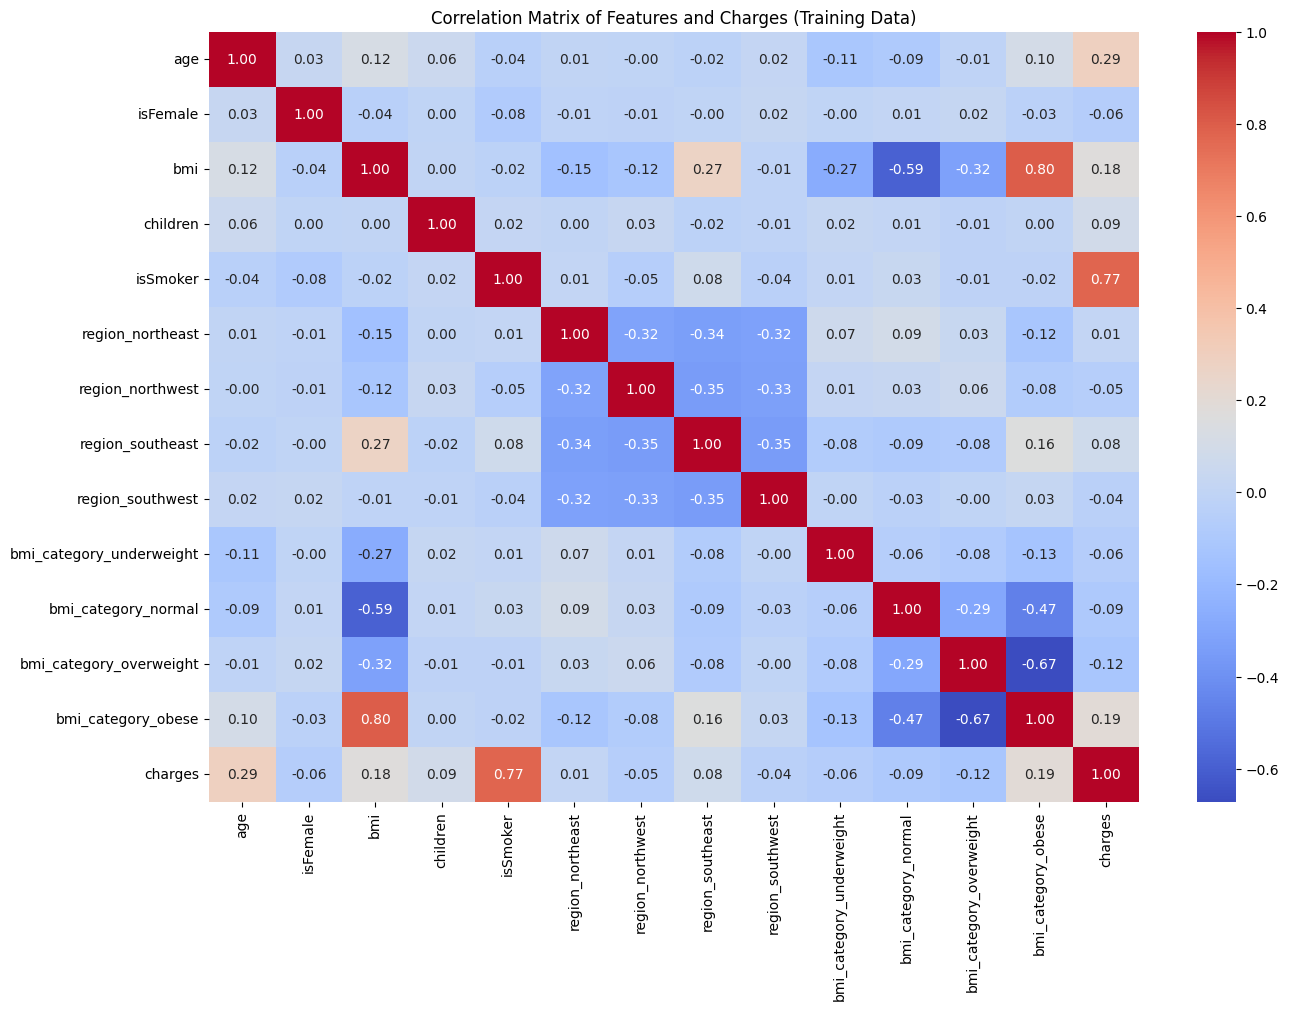

In [ ]:
# Combine X_train and y_train for correlation analysis
train_df = pd.concat([X_train, y_train], axis=1)

# Compute the correlation matrix
correlation_matrix = train_df.corr()

# Plot the heatmap
plt.figure(figsize=(15, 10))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix of Features and Charges (Training Data)')
plt.show()

In [ ]:
df_cleaned = df_cleaned.astype(int)

In [ ]:
df_cleaned.head()

,age,sex,bmi,children,smoker,charges,region_northeast,region_northwest,region_southeast,region_southwest
0,19,1,27,0,1,16884,0,0,0,1
1,18,0,33,1,0,1725,0,0,1,0
2,28,0,33,3,0,4449,0,0,1,0
3,33,0,22,0,0,21984,0,1,0,0
4,32,0,28,0,0,3866,0,1,0,0


<Axes: xlabel='bmi', ylabel='Count'>

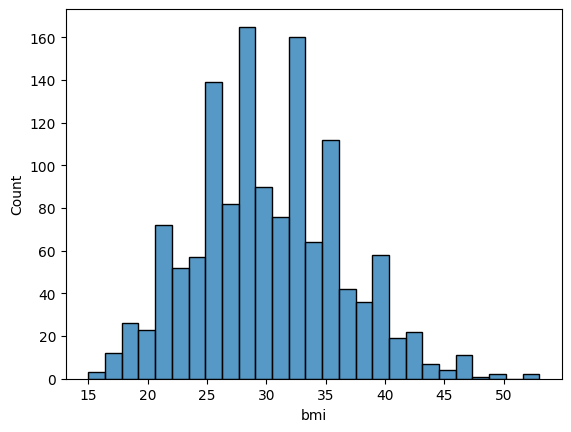

In [ ]:
# Feature Engineering and Extraction

sns.histplot(df_cleaned["bmi"])

In [ ]:
df_cleaned["bmi_category"] = pd.cut(df_cleaned["bmi"], bins = [0, 18.5, 24.9, 29.9, float("inf")],
                                    labels = ["underweight", "normal", "overweight", "obese"])

In [ ]:
df_cleaned.head()

,age,sex,bmi,children,smoker,charges,region_northeast,region_northwest,region_southeast,region_southwest,bmi_category
0,19,1,27,0,1,16884,0,0,0,1,overweight
1,18,0,33,1,0,1725,0,0,1,0,obese
2,28,0,33,3,0,4449,0,0,1,0,obese
3,33,0,22,0,0,21984,0,1,0,0,normal
4,32,0,28,0,0,3866,0,1,0,0,overweight


In [ ]:
df_cleaned = pd.get_dummies(df_cleaned, columns = ["bmi_category"])
df_cleaned = df_cleaned.astype(int)

In [ ]:
df_cleaned.head()

,age,sex,bmi,children,smoker,charges,region_northeast,region_northwest,region_southeast,region_southwest,bmi_category_underweight,bmi_category_normal,bmi_category_overweight,bmi_category_obese
0,19,1,27,0,1,16884,0,0,0,1,0,0,1,0
1,18,0,33,1,0,1725,0,0,1,0,0,0,0,1
2,28,0,33,3,0,4449,0,0,1,0,0,0,0,1
3,33,0,22,0,0,21984,0,1,0,0,0,1,0,0
4,32,0,28,0,0,3866,0,1,0,0,0,0,1,0


In [ ]:
df_cleaned.columns

Index(['age', 'sex', 'bmi', 'children', 'smoker', 'charges',
       'region_northeast', 'region_northwest', 'region_southeast',
       'region_southwest', 'bmi_category_underweight', 'bmi_category_normal',
       'bmi_category_overweight', 'bmi_category_obese'],
      dtype='object')

In [ ]:
from sklearn.preprocessing import StandardScaler

In [ ]:
cols = ["age", "bmi", "children"]

In [ ]:
scaler = StandardScaler()
df_cleaned[cols] = scaler.fit_transform(df_cleaned[cols])
df_cleaned.head()

,age,sex,bmi,children,smoker,charges,region_northeast,region_northwest,region_southeast,region_southwest,bmi_category_underweight,bmi_category_normal,bmi_category_overweight,bmi_category_obese
0,-1.440418,1,-0.517949,-0.909234,1,16884,0,0,0,1,0,0,1,0
1,-1.511647,0,0.462463,-0.079442,0,1725,0,0,1,0,0,0,0,1
2,-0.799350,0,0.462463,1.580143,0,4449,0,0,1,0,0,0,0,1
3,-0.443201,0,-1.334960,-0.909234,0,21984,0,1,0,0,0,1,0,0
4,-0.514431,0,-0.354547,-0.909234,0,3866,0,1,0,0,0,0,1,0
